In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm , datasets
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score

In [14]:
x,y= datasets.make_blobs(n_samples=100 ,centers=2 , random_state=6)


In [15]:
x

array([[  8.21597398,  -2.28672255],
       [  5.42916264,  -9.28019465],
       [  7.4816983 ,  -2.96403632],
       [  7.93333064,  -3.51553205],
       [  7.29573215,  -4.39392379],
       [  5.73072844,  -2.60895506],
       [  7.9683312 ,  -3.23125265],
       [  6.70309926,  -9.59360762],
       [  7.83762169,  -1.69756104],
       [  7.69483605,  -2.63359393],
       [  6.3649649 ,  -8.97189915],
       [  9.24223825,  -3.88003098],
       [  9.07568367,  -4.21790533],
       [  7.11707557,  -8.20473416],
       [  5.22323107,  -8.27441475],
       [  8.21073365,  -4.00374119],
       [  6.94147717,  -8.23721012],
       [  6.54118443,  -9.84832481],
       [  9.42169269,  -2.6476988 ],
       [  5.97933839,  -9.30802671],
       [  5.20200675,  -8.34325489],
       [  8.07502382,  -4.25949569],
       [  7.80996597,  -4.80944368],
       [  8.03349337,  -2.26578348],
       [  7.20721285,  -9.65948603],
       [  6.36448985,  -9.73455578],
       [  6.47613341,  -9.38565474],
 

In [16]:
y

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1])

In [17]:
x_train,x_test,y_train,y_test=train_test_split (x,y,test_size=0.3 ,random_state=42)

In [18]:
linear_svm=svm.SVC(kernel='linear')
linear_svm.fit(x_train, y_train)
y_pred_linear=linear_svm.predict(x_test)

In [19]:
accuracy_linear=accuracy_score(y_test,y_pred_linear)
print(f"linear SVM Accuracy : {accuracy_linear* 100:.2f}%")

linear SVM Accuracy : 100.00%


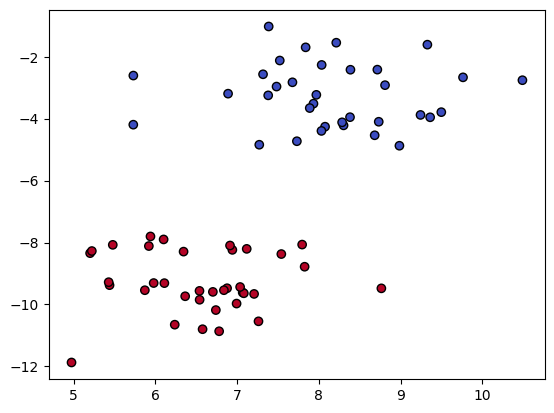

In [24]:
plt.Figure(figsize=(5,6))
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
ax=plt.gca()
xlim = ax.get_xlim
ylim = ax.get_ylim

SVM Hyperplane and Margins

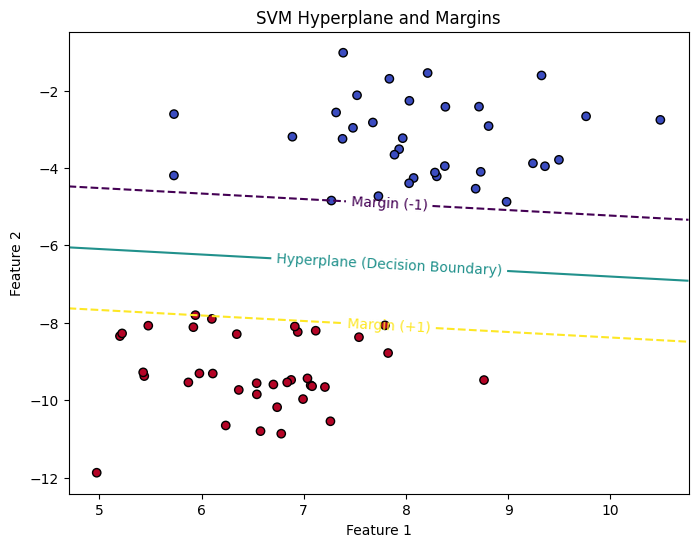

In [26]:
#  Plot Decision Boundary with Labels

plt.figure(figsize=(8, 6))

# Plot data points
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c=y_train,
    cmap=plt.cm.coolwarm,
    edgecolors='k'
)

# Get axis limits
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)

# Combine grid points
grid_points = np.vstack([XX.ravel(), YY.ravel()]).T

# Decision function
Z = linear_svm.decision_function(grid_points)
Z = Z.reshape(XX.shape)

# Plot hyperplane and margins
contours = ax.contour(
    XX, YY, Z,
    levels=[-1, 0, 1],
    linestyles=['--', '-', '--']
)

# Label the lines
fmt = {
    -1: "Margin (-1)",
     0: "Hyperplane (Decision Boundary)",
     1: "Margin (+1)"
}
ax.clabel(contours, inline=True, fontsize=10, fmt=fmt)

# Labels and title
plt.title("SVM Hyperplane and Margins")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()


In [28]:
# Create a synthetic dataset (non-linearly separable, e.g., circles)
X, y = datasets.make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# Split the dataset into training and test sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
rbf_svm = svm.SVC(kernel='rbf', gamma='scale')  # 'gamma' controls the influence of a single training example

# Train the model
rbf_svm.fit(x_train, y_train)

# Make predictions
y_pred_rbf = rbf_svm.predict(x_test)

In [32]:
#evaluate accuracy
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Non-linear SVM (RBF) Accuracy: {accuracy_rbf * 100:.1f}%")

Non-linear SVM (RBF) Accuracy: 98.3%


Non-linear SVM Decision Boundary RBF Kernel

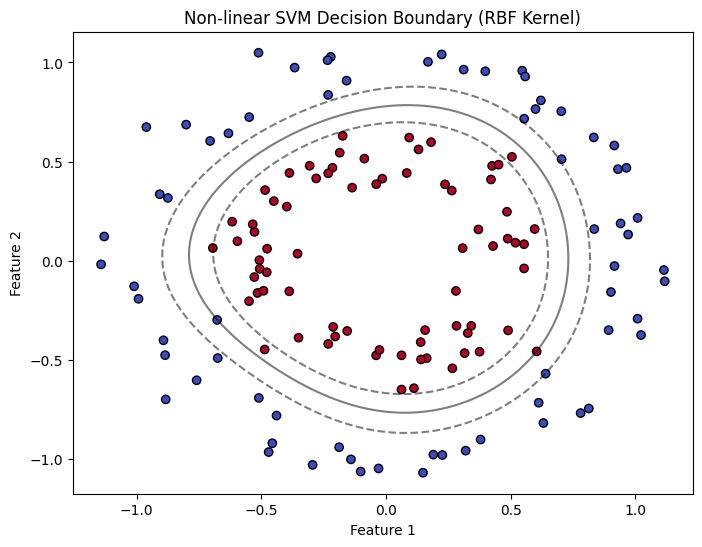

In [33]:
# Plot decision boundary for Non-linear SVM
plt.figure(figsize=(8, 6))
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = rbf_svm.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-0.5, 0, 0.5], alpha=0.5, linestyles=['--', '-', '--'])
plt.title("Non-linear SVM Decision Boundary (RBF Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Linear SVM Straight Line

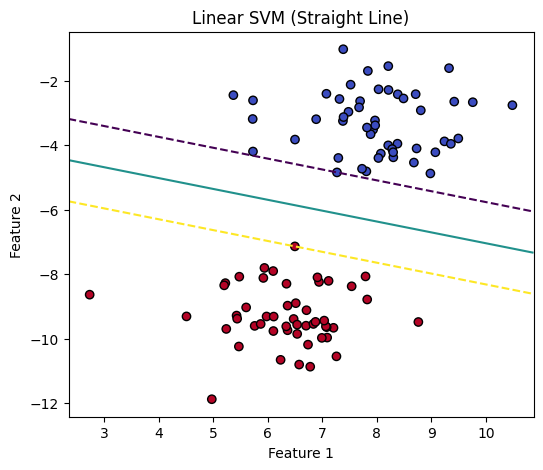

In [34]:
# Create simple linearly separable data
X1, y1 = datasets.make_blobs(n_samples=100, centers=2, random_state=6)

# Train Linear SVM
model1 = svm.SVC(kernel='linear')
model1.fit(X1, y1)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X1[:,0], X1[:,1], c=y1, cmap=plt.cm.coolwarm, edgecolors='k')

# Create grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict on grid
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model1.decision_function(xy).reshape(XX.shape)

# Plot boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("Linear SVM (Straight Line)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Non-Linear SVM RBF Kernel

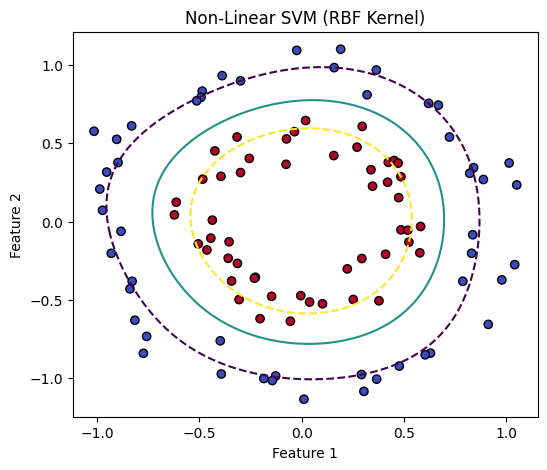

In [35]:
# Create circular data (not linearly separable)
X2, y2 = datasets.make_circles(n_samples=100, factor=0.5, noise=0.1)

# Train RBF SVM
model2 = svm.SVC(kernel='rbf')
model2.fit(X2, y2)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap=plt.cm.coolwarm, edgecolors='k')

# Grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model2.decision_function(xy).reshape(XX.shape)

# Plot curved boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("Non-Linear SVM (RBF Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

polynomial svm

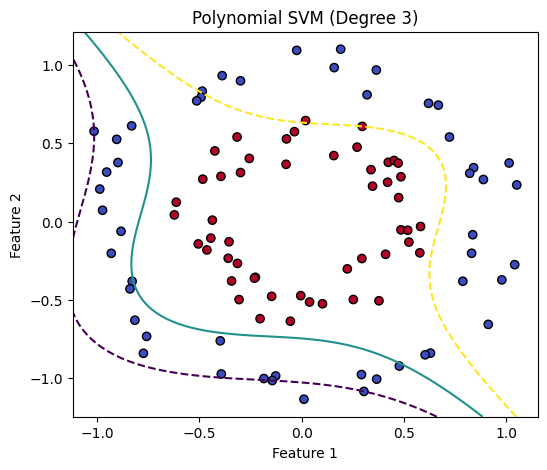

In [36]:

# Use same data
model3 = svm.SVC(kernel='poly', degree=3)
model3.fit(X2, y2)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap=plt.cm.coolwarm, edgecolors='k')

# Grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model3.decision_function(xy).reshape(XX.shape)

# Plot polynomial boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("Polynomial SVM (Degree 3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

 CIRCULAR DATA (Clear Non-linear Case)

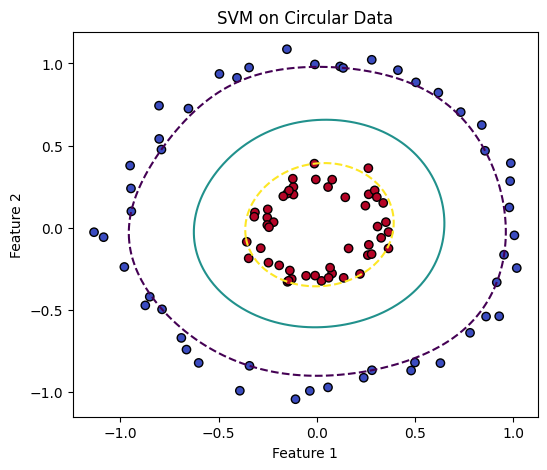

In [37]:
# 4. CIRCULAR DATA (Clear Non-linear Case)

# Create tighter circle data
X3, y3 = datasets.make_circles(n_samples=100, factor=0.3, noise=0.05)

# Train RBF SVM
model4 = svm.SVC(kernel='rbf')
model4.fit(X3, y3)

# Plot data
plt.figure(figsize=(6,5))
plt.scatter(X3[:,0], X3[:,1], c=y3, cmap=plt.cm.coolwarm, edgecolors='k')

# Grid
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Predict
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model4.decision_function(xy).reshape(XX.shape)

# Plot circular boundary
ax.contour(XX, YY, Z, levels=[-1,0,1], linestyles=['--','-','--'])

plt.title("SVM on Circular Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()